In [162]:
import os, sys, time, random, warnings
from collections import deque
from pathlib import Path
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, callbacks, optimizers, applications
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, f1_score
warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
OpenCV: 4.13.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [124]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [125]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/CCP/FER.zip"
extract_path = "/content/FER"

# unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" Unzipped successfully!")

 Unzipped successfully!


In [126]:
from pathlib import Path

TRAIN_DIR = Path("/content/FER/train")
TEST_DIR  = Path("/content/FER/test")

# emotions detect
EMOTIONS = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(EMOTIONS)

print("Emotion classes:", EMOTIONS)
print("Num classes:", NUM_CLASSES)

# correct function
def count_images(folder, emotion):
    return len(list((folder / emotion).glob("*")))  # jpg/png both safe

# per-class counts
print("\nTrain images per class:")
for e in EMOTIONS:
    print(e, ":", count_images(TRAIN_DIR, e))

print("\nTest images per class:")
for e in EMOTIONS:
    print(e, ":", count_images(TEST_DIR, e))

train_count = sum(count_images(TRAIN_DIR, e) for e in EMOTIONS)
test_count  = sum(count_images(TEST_DIR, e) for e in EMOTIONS)

print("\nTotal Train images:", train_count)
print("Total Test images:", test_count)

Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Num classes: 7

Train images per class:
angry : 3995
disgust : 436
fear : 4097
happy : 7215
neutral : 4965
sad : 4830
surprise : 3171

Test images per class:
angry : 958
disgust : 111
fear : 1024
happy : 1774
neutral : 1233
sad : 1247
surprise : 831

Total Train images: 28709
Total Test images: 7178


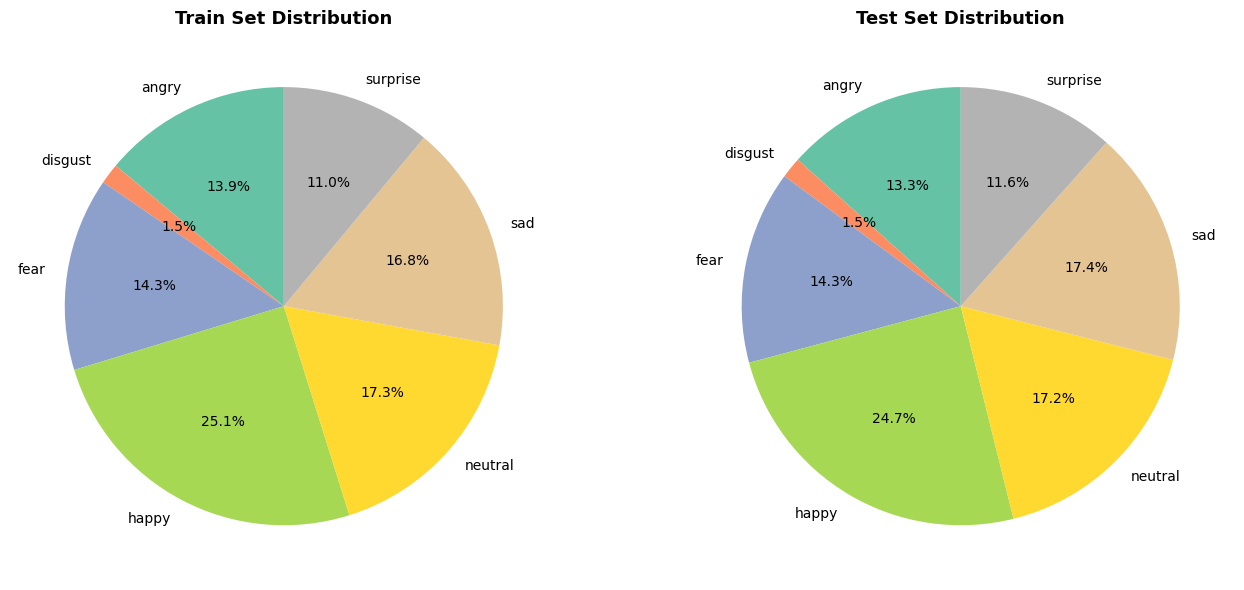

Total train samples: 28709
Total test samples: 7178


In [127]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, folder, title in zip(
    axes,
    [TRAIN_DIR, TEST_DIR],
    ['Train Set Distribution', 'Test Set Distribution']
):

    counts = {
        e: count_images(folder, e)
        for e in EMOTIONS
    }

    values = list(counts.values())
    labels = list(counts.keys())

    # PIE CHART
    ax.pie(
        values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set2(np.linspace(0, 1, len(counts)))
    )

    ax.set_title(title, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution_pie.png', dpi=150, bbox_inches='tight')
plt.show()

train_total = sum(count_images(TRAIN_DIR, e) for e in EMOTIONS)
test_total  = sum(count_images(TEST_DIR, e) for e in EMOTIONS)

print("Total train samples:", train_total)
print("Total test samples:", test_total)

In [128]:
IMG_SIZE_GRAY = 48
IMG_SIZE_COLOR = 96
BATCH_SIZE = 64
EPOCHS_SCRATCH = 50
EPOCHS_FINETUNE = 20

def preprocess_face_gray(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    eq = clahe.apply(blurred)

    resized = cv2.resize(eq, (IMG_SIZE_GRAY, IMG_SIZE_GRAY))
    norm = resized.astype('float32') / 255.0

    return norm[..., np.newaxis]


def preprocess_face_color(img_bgr):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (IMG_SIZE_COLOR, IMG_SIZE_COLOR))

    return applications.mobilenet_v2.preprocess_input(
        resized.astype('float32')
    )

print("Preprocessing functions Completed")

Preprocessing functions Completed


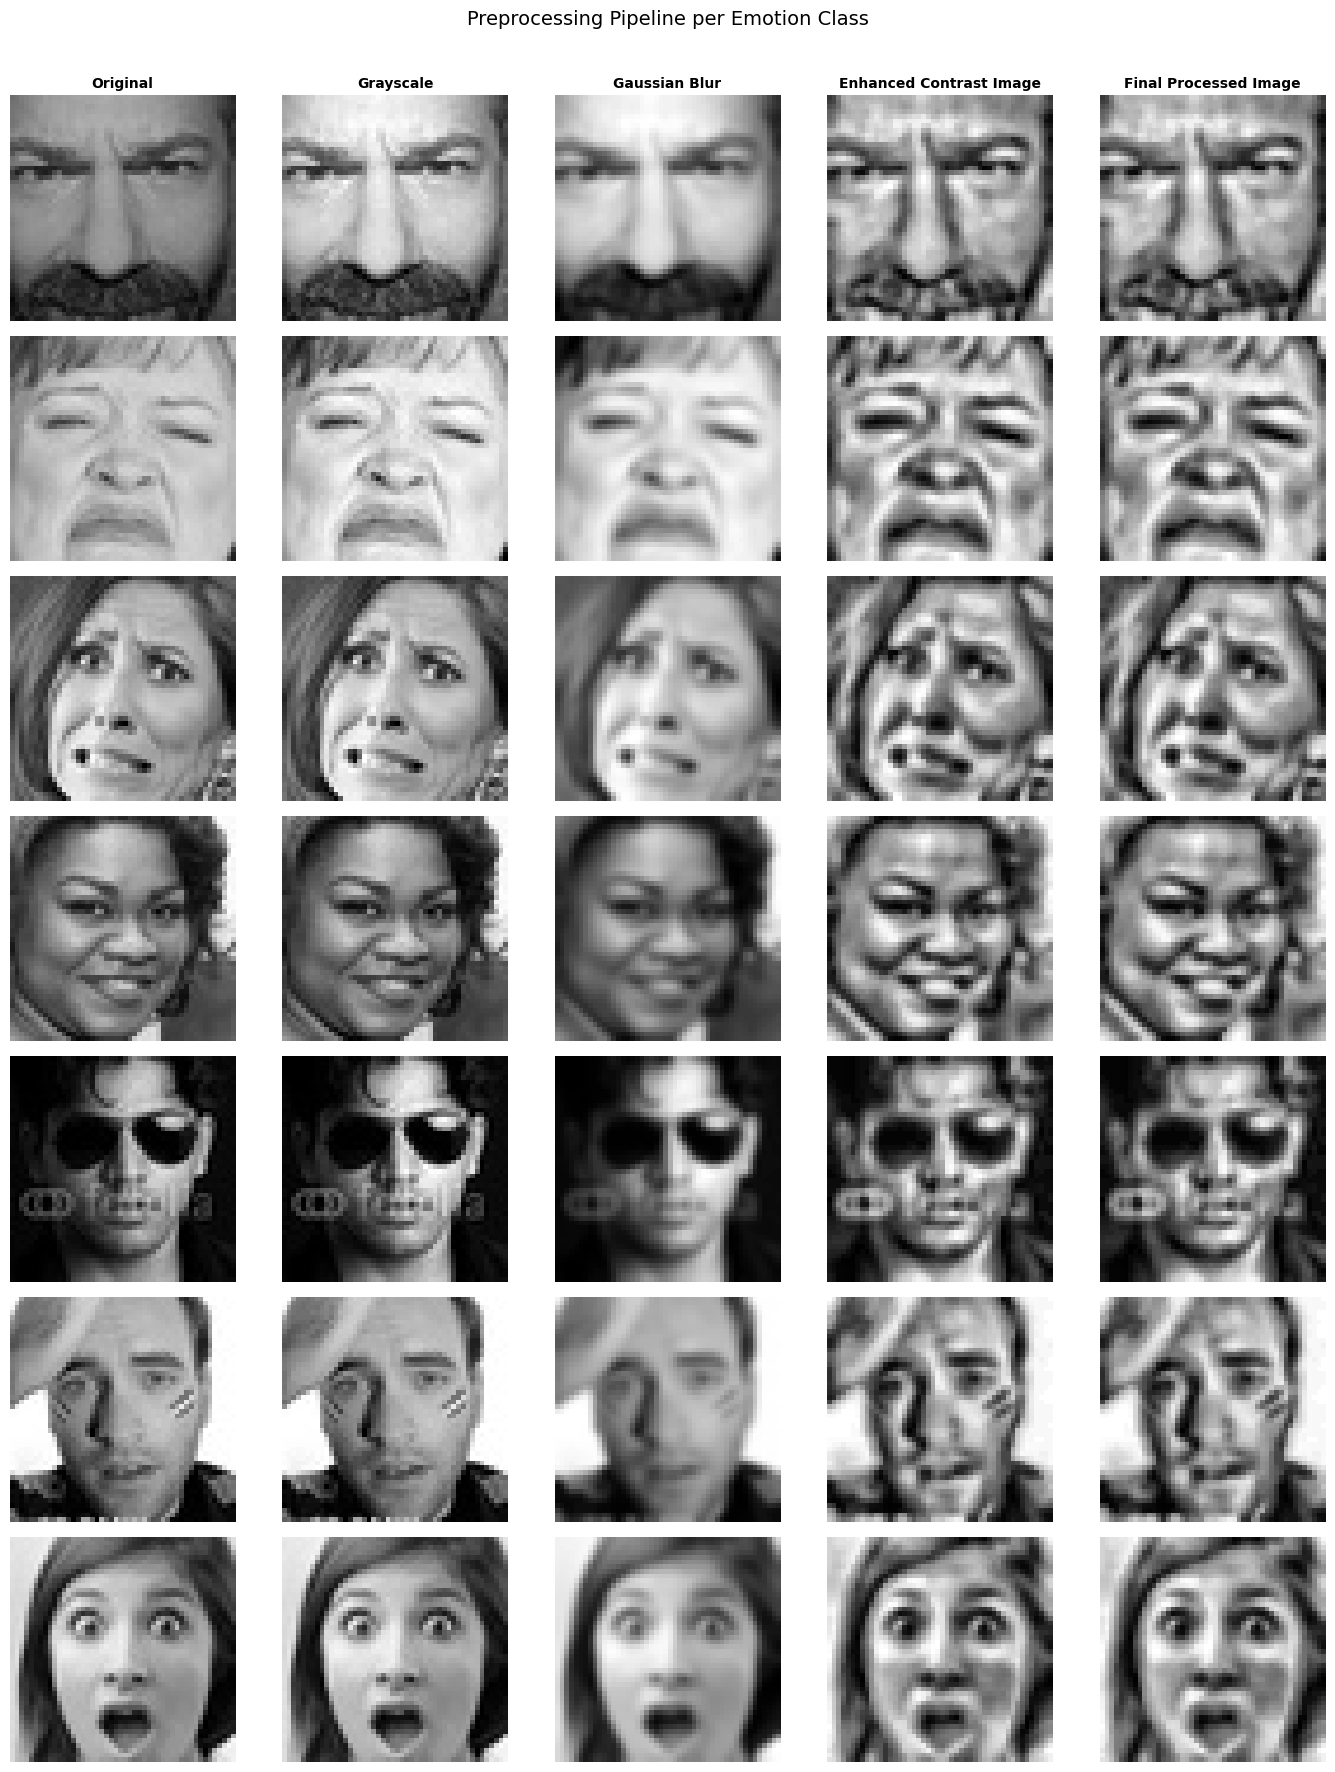

In [129]:
fig, axes = plt.subplots(len(EMOTIONS), 5, figsize=(14, 2.5 * len(EMOTIONS)))

steps = ['Original', 'Grayscale', 'Gaussian Blur', 'Enhanced Contrast Image', 'Final Processed Image']

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

for row, emotion in enumerate(EMOTIONS):

    img_list = list((TRAIN_DIR / emotion).glob("*.jpg"))

    # safety check
    if len(img_list) == 0:
        print(f" No images found in {emotion}")
        continue

    img_path = img_list[0]
    img_bgr = cv2.imread(str(img_path))

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    eq = clahe.apply(blurred)
    resized = cv2.resize(eq, (IMG_SIZE_GRAY, IMG_SIZE_GRAY))

    imgs = [
        cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
        gray,
        blurred,
        eq,
        resized
    ]

    cmaps = [None, 'gray', 'gray', 'gray', 'gray']

    for col, (im, cmap, step) in enumerate(zip(imgs, cmaps, steps)):
        axes[row, col].imshow(im, cmap=cmap)
        axes[row, col].axis('off')

        if row == 0:
            axes[row, col].set_title(step, fontsize=10, fontweight='bold')

        if col == 0:
            axes[row, col].set_ylabel(emotion, fontsize=9, rotation=90, labelpad=10)

plt.suptitle('Preprocessing Pipeline per Emotion Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('preprocessing_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

In [130]:
def preprocess_gray(file_path, label):  # For both CNN & VGG
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=1)
    image = tf.image.resize(image, (IMG_SIZE_GRAY, IMG_SIZE_GRAY))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def preprocess_color(file_path, label):  # for MobileNet
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE_COLOR, IMG_SIZE_COLOR))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(
        tf.cast(image, tf.float32)
    )
    return image, label


# AUGMENTATION

def apply_augmentation(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    return image, label

# DATASET BUILDER

def create_dataset(data_dir, preprocess_fn, augment=False, shuffle=True):

    paths, labels = [], []

    for idx, emotion in enumerate(EMOTIONS):
        img_files = list((data_dir / emotion).glob("*.jpg"))

        paths.extend([str(p) for p in img_files])
        labels.extend([idx] * len(img_files))

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, tf.one_hot(labels, NUM_CLASSES))
    )

    if shuffle:
        dataset = dataset.shuffle(len(paths), seed=42)

    dataset = dataset.map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        dataset = dataset.map(apply_augmentation, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset

# BUILD DATASETS

train_gray = create_dataset(TRAIN_DIR, preprocess_gray, augment=True)
val_gray   = create_dataset(TEST_DIR, preprocess_gray, augment=False, shuffle=False)

train_color = create_dataset(TRAIN_DIR, preprocess_color, augment=True)
val_color   = create_dataset(TEST_DIR, preprocess_color, augment=False, shuffle=False)

# SUMMARY

print("Dataset Summary")
print("Gray train batches :", len(train_gray))
print("Gray val batches   :", len(val_gray))
print("Color train batches:", len(train_color))
print("Color val batches  :", len(val_color))

Dataset Summary
Gray train batches : 449
Gray val batches   : 113
Color train batches: 449
Color val batches  : 113


In [131]:
# MODEL BUILD
def build_cnn(input_shape=(48, 48, 1), NUM_CLASSES=7):

    inp = layers.Input(shape=input_shape, name='input')

    # First Block with 32 filters
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Second Block with 64 filters
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Third Block with 128 filters
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs=inp, outputs=out, name='build_cnn')

    return model


scratch_model = build_cnn()
scratch_model.summary()

print(f"\nTrainable params: {scratch_model.count_params():,}")

Model: "build_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_72          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_73          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_74          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_85 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_86 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_27     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 323,047 (1.23 MB)

 Trainable params: 322,151 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)


Trainable params: 323,047


In [132]:
def pretrained_model(input_shape=(96, 96, 3), num_classes=7, trainable=False):

    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze or fine-tune backbone
    if not trainable:
        base.trainable = False
    else:
        base.trainable = True

        # fine-tune last 30 layers only
        for layer in base.layers[:-30]:
            layer.trainable = False
        for layer in base.layers[-30:]:
            layer.trainable = True

    inp = layers.Input(shape=input_shape, name='input_color')

    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)

    name = 'mobilenetv2_frozen' if not trainable else 'mobilenetv2_finetuned'
    model = models.Model(inp, out, name=name)

    return model


# TEST
pretrained_frozen_model = pretrained_model(trainable=False)
pretrained_frozen_model.summary()

print(f"\nTrainable params: {pretrained_frozen_model.count_params():,}")

Model: "mobilenetv2_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_color (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_28     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_88 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_89 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046,983 (11.62 MB)

 Trainable params: 788,999 (3.01 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params: 3,046,983


In [133]:
def vggdouble_convblock(x, filters, dropout_rate=0.3, name=''):
    x = layers.Conv2D(filters, 3, padding='same', name=f'{name}_conv1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', name=f'{name}_conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x


def vggstyle_model(input_shape=(48, 48, 1), num_classes=7):
    inp = layers.Input(shape=input_shape, name='input_vgg')

    x = vggdouble_convblock(inp, 32,  dropout_rate=0.25, name='block1')
    x = vggdouble_convblock(x,   64,  dropout_rate=0.25, name='block2')
    x = vggdouble_convblock(x,   128, dropout_rate=0.30, name='block3')

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inp, out, name='vgg_style')
    return model

vgg_model = vggstyle_model()
vgg_model.summary()
print(f"\nTrainable params: {vgg_model.count_params():,}")

Model: "vgg_style"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_vgg (InputLayer)          │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_79          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_90 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_80          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_81          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_91 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_82          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_83          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 487,399 (1.86 MB)

 Trainable params: 486,503 (1.86 MB)

 Non-trainable params: 896 (3.50 KB)


Trainable params: 487,399


In [134]:
def get_callbacks(model_name):
    return [
        callbacks.ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_accuracy', save_best_only=True, verbose=1),
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=8,
            restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=4,
            min_lr=1e-6, verbose=1),
    ]

In [135]:
def compile_and_train(model, train_ds, val_ds, epochs, lr=1e-3, model_name='model'):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    t0 = time.time()
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=epochs,
        callbacks=get_callbacks(model_name),
        verbose=1
    )
    elapsed = time.time() - t0
    print(f"\n⏱  Training time: {elapsed/60:.1f} min")
    return history, elapsed

In [136]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(history.history[metric],       label='Train', linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label='Val',   linewidth=2)
        ax.set_title(f'{title} — {metric.capitalize()}', fontsize=12)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}_history.png',
                dpi=150, bbox_inches='tight')
    plt.show()

In [164]:
history_scratch, time_scratch = compile_and_train(
    scratch_model,
    train_gray,
    val_gray,
    epochs=EPOCHS_SCRATCH,
    lr=1e-3,
    model_name="CNN"
)

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2601 - loss: 1.8337
Epoch 1: val_accuracy improved from None to 0.27779, saving model to best_CNN.keras

Epoch 1: finished saving model to best_CNN.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.3135 - loss: 1.7103 - val_accuracy: 0.2778 - val_loss: 1.9593 - learning_rate: 0.0010
Epoch 2/50
447/449 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4482 - loss: 1.4384
Epoch 2: val_accuracy improved from 0.27779 to 0.46977, saving model to best_CNN.keras

Epoch 2: finished saving model to best_CNN.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.4692 - loss: 1.3933 - val_accuracy: 0.4698 - val_loss: 1.3958 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5117 - loss: 1.2838
Epoch 3: val_accuracy improved from 0.46977 to 0.50557, saving model to best_CNN.keras

Epoch 3: finished saving model to best_CNN.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - ac

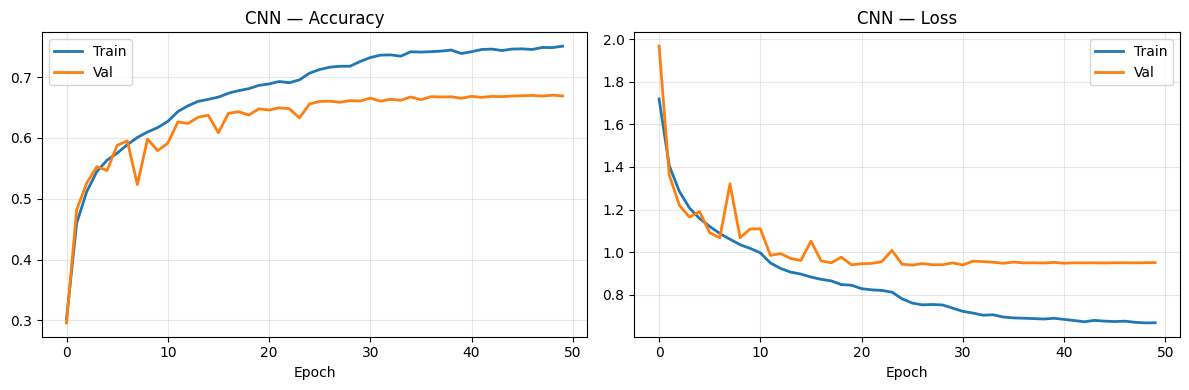

In [138]:
plot_history(history_scratch, 'CNN')

 TRAINING MODEL 2a: MobileNetV2 Frozen Backbone
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3350 - loss: 1.7184
Epoch 1: val_accuracy improved from None to 0.44845, saving model to best_mobilenet_frozen.keras

Epoch 1: finished saving model to best_mobilenet_frozen.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 37s 61ms/step - accuracy: 0.3741 - loss: 1.6075 - val_accuracy: 0.4485 - val_loss: 1.4516 - learning_rate: 0.0010
Epoch 2/20
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4247 - loss: 1.4920
Epoch 2: val_accuracy improved from 0.44845 to 0.46865, saving model to best_mobilenet_frozen.keras

Epoch 2: finished saving model to best_mobilenet_frozen.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.4321 - loss: 1.4813 - val_accuracy: 0.4687 - val_loss: 1.3912 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4514 - loss: 1.4308
Epoch 3: val_accuracy improved from 0.46865 to 0.48245, saving model to best_mobil

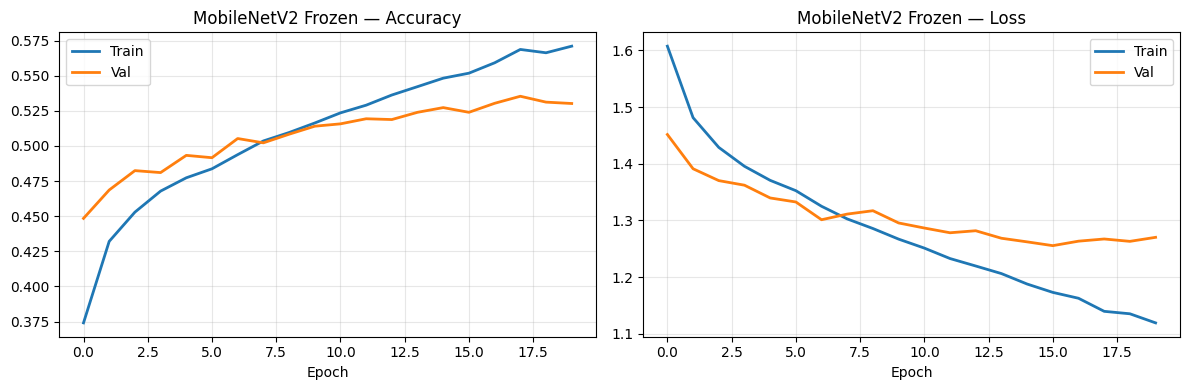

In [139]:
print(" TRAINING MODEL 2a: MobileNetV2 Frozen Backbone")

pretrained_frozen_model = pretrained_model(trainable=False)

history_frozen, time_frozen = compile_and_train(
    pretrained_frozen_model,
    train_color,
    val_color,
    epochs=20,
    lr=1e-3,
    model_name="mobilenet_frozen"
)

plot_history(history_frozen, "MobileNetV2 Frozen")

TRAINING MODEL 2b: MobileNetV2 Fine-tuned
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3335 - loss: 1.7318
Epoch 1: val_accuracy improved from None to 0.40345, saving model to best_mobilenet_finetuned.keras

Epoch 1: finished saving model to best_mobilenet_finetuned.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 46s 63ms/step - accuracy: 0.3996 - loss: 1.5630 - val_accuracy: 0.4035 - val_loss: 1.5322 - learning_rate: 1.0000e-04
Epoch 2/20
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5117 - loss: 1.2840
Epoch 2: val_accuracy improved from 0.40345 to 0.49526, saving model to best_mobilenet_finetuned.keras

Epoch 2: finished saving model to best_mobilenet_finetuned.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.5214 - loss: 1.2676 - val_accuracy: 0.4953 - val_loss: 1.3332 - learning_rate: 1.0000e-04
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5749 - loss: 1.1307
Epoch 3: val_accuracy improved from 0.49526 to 0.53079, saving model

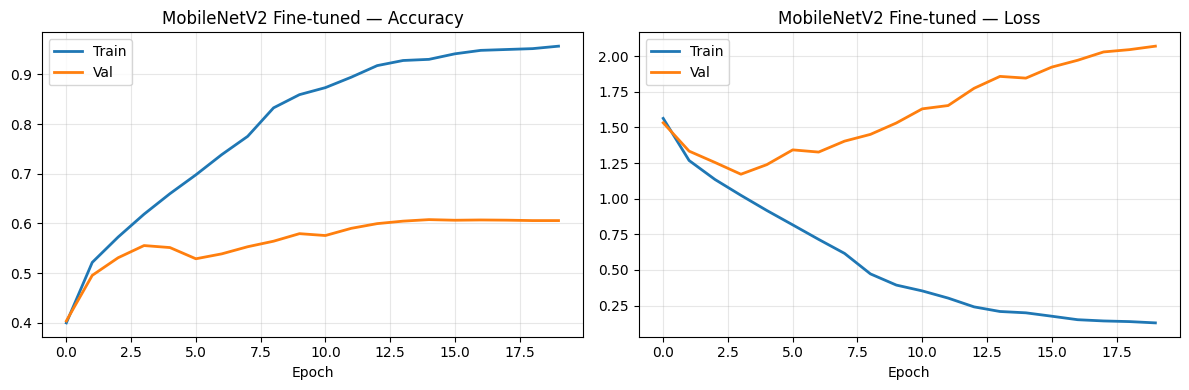

In [140]:
print("TRAINING MODEL 2b: MobileNetV2 Fine-tuned")

finetuned_model = pretrained_model(trainable=True)
history_finetune, time_finetune = compile_and_train(
    finetuned_model, train_color, val_color,
    epochs=EPOCHS_FINETUNE, lr=1e-4,
    model_name='mobilenet_finetuned'
)
plot_history(history_finetune, 'MobileNetV2 Fine-tuned')

TRAINING MODEL 3: VGG-Style Double Conv Block
Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2284 - loss: 1.8491
Epoch 1: val_accuracy improved from None to 0.23196, saving model to best_vgg_style.keras

Epoch 1: finished saving model to best_vgg_style.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.2518 - loss: 1.8006 - val_accuracy: 0.2320 - val_loss: 2.0310 - learning_rate: 0.0010
Epoch 2/50
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3285 - loss: 1.6585
Epoch 2: val_accuracy improved from 0.23196 to 0.35428, saving model to best_vgg_style.keras

Epoch 2: finished saving model to best_vgg_style.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3600 - loss: 1.6015 - val_accuracy: 0.3543 - val_loss: 1.6276 - learning_rate: 0.0010
Epoch 3/50
446/449 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4345 - loss: 1.4687
Epoch 3: val_accuracy improved from 0.35428 to 0.44009, saving model to best_vgg_style.keras

Epoch 3: finished 

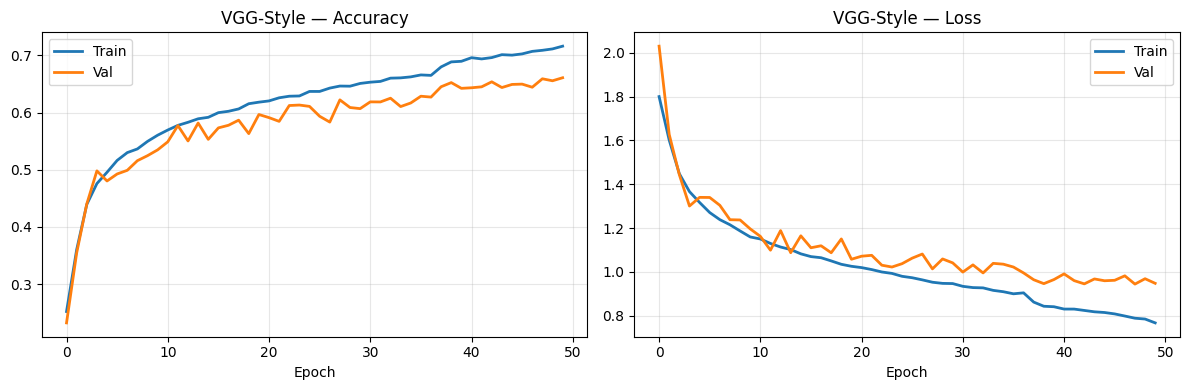

In [163]:
print("TRAINING MODEL 3: VGG-Style Double Conv Block")

vgg_model = vggstyle_model()
history_vgg, time_vgg = compile_and_train(
    vgg_model, train_gray, val_gray,
    epochs=EPOCHS_SCRATCH, lr=1e-3, model_name='vgg_style'
)
plot_history(history_vgg, 'VGG-Style')

In [165]:
CNN = tf.keras.models.load_model('best_scratch_cnn.keras')
frozen = tf.keras.models.load_model('best_mobilenet_frozen.keras')
finetune = tf.keras.models.load_model('best_mobilenet_finetuned.keras')
vgg = tf.keras.models.load_model('best_vgg_style.keras')
print("All models loaded.")

All models loaded.


In [166]:
def evaluate_model(model, dataset, model_name):


    y_true, y_pred = [], []

    for x, y in dataset:
        preds = model.predict(x, verbose=0)

        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(y.numpy(), axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("MODEL:", model_name)

    print(classification_report(y_true, y_pred, target_names=EMOTIONS))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=EMOTIONS,
                yticklabels=EMOTIONS)

    plt.title(model_name + " Confusion Matrix")
    plt.show()

MODEL: CNN 
              precision    recall  f1-score   support

       angry       0.61      0.59      0.60       958
     disgust       0.73      0.57      0.64       111
        fear       0.57      0.43      0.49      1024
       happy       0.85      0.87      0.86      1774
     neutral       0.59      0.70      0.64      1233
         sad       0.56      0.57      0.56      1247
    surprise       0.78      0.81      0.79       831

    accuracy                           0.68      7178
   macro avg       0.67      0.65      0.66      7178
weighted avg       0.67      0.68      0.67      7178



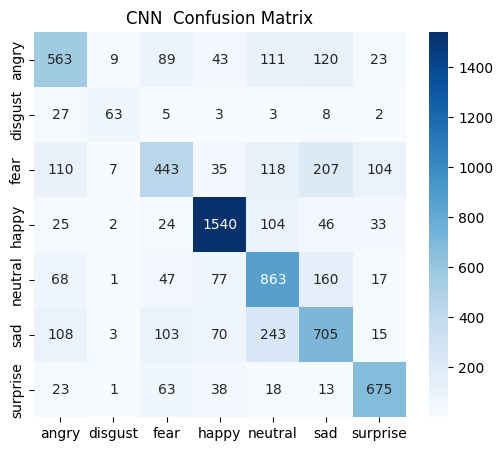

In [167]:
evaluate_model(scratch_model, val_gray, "CNN ")

MODEL: VGG Style
              precision    recall  f1-score   support

       angry       0.59      0.60      0.60       958
     disgust       0.70      0.41      0.52       111
        fear       0.53      0.35      0.42      1024
       happy       0.88      0.86      0.87      1774
     neutral       0.61      0.63      0.62      1233
         sad       0.50      0.61      0.55      1247
    surprise       0.74      0.84      0.79       831

    accuracy                           0.66      7178
   macro avg       0.65      0.62      0.62      7178
weighted avg       0.66      0.66      0.66      7178



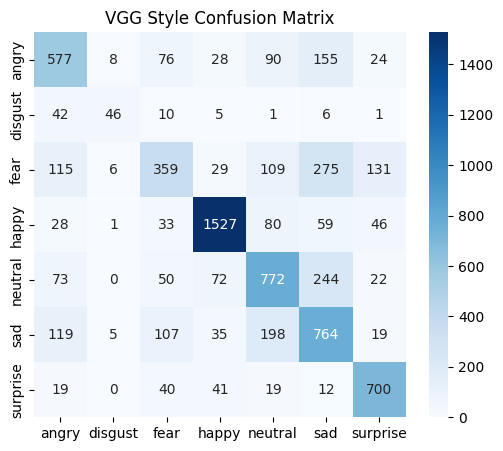

In [168]:
evaluate_model(vgg_model, val_gray, "VGG Style")

MODEL: MobileNet Frozen
              precision    recall  f1-score   support

       angry       0.46      0.35      0.40       958
     disgust       0.51      0.32      0.39       111
        fear       0.42      0.38      0.40      1024
       happy       0.67      0.73      0.70      1774
     neutral       0.46      0.56      0.51      1233
         sad       0.44      0.43      0.44      1247
    surprise       0.69      0.67      0.68       831

    accuracy                           0.54      7178
   macro avg       0.52      0.49      0.50      7178
weighted avg       0.53      0.54      0.53      7178



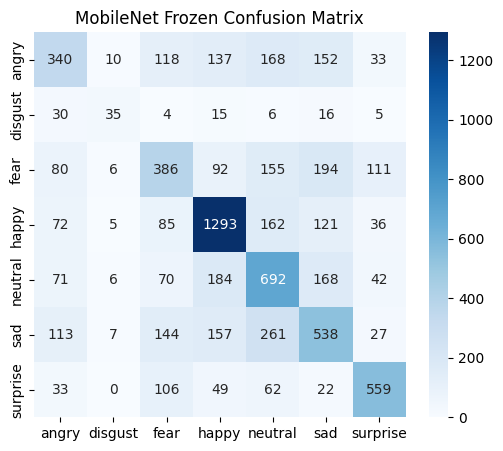

In [156]:
evaluate_model(pretrained_frozen_model, val_color, "MobileNet Frozen")

MODEL: MobileNet Finetune
              precision    recall  f1-score   support

       angry       0.53      0.50      0.51       958
     disgust       0.58      0.58      0.58       111
        fear       0.52      0.44      0.48      1024
       happy       0.73      0.83      0.78      1774
     neutral       0.52      0.58      0.55      1233
         sad       0.54      0.43      0.48      1247
    surprise       0.71      0.79      0.75       831

    accuracy                           0.61      7178
   macro avg       0.59      0.59      0.59      7178
weighted avg       0.60      0.61      0.60      7178



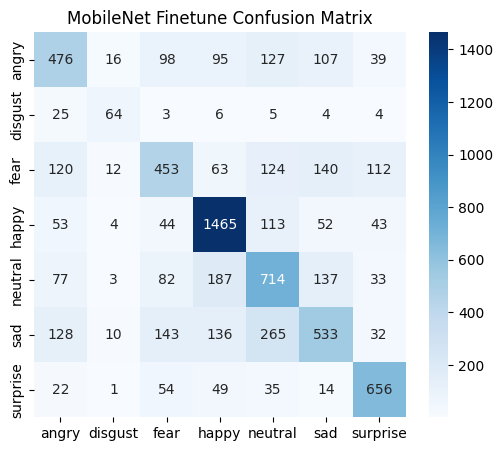

In [157]:
evaluate_model(finetuned_model, val_color, "MobileNet Finetune")

In [169]:
def get_model_accuracy(model, dataset, model_name):
    y_true, y_pred = [], []

    for x, y in dataset:
        preds = model.predict(x, verbose=0)

        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(y.numpy(), axis=1))

    acc = accuracy_score(y_true, y_pred)

    return {
        "Model Name": model_name,
        "Accuracy": round(acc * 100, 2)
    }


# Collect results for all models
results = []

results.append(get_model_accuracy(scratch_model, val_gray, "CNN"))
results.append(get_model_accuracy(vgg_model, val_gray, "VGG Style"))
results.append(get_model_accuracy(pretrained_frozen_model, val_color, "MobileNet Frozen"))
results.append(get_model_accuracy(finetuned_model, val_color, "MobileNet Finetune"))


# Create comparison table
comparison_df = pd.DataFrame(results)

# Sort by best accuracy
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n ***** MODEL COMPARISON TABLE ***** \n")
print(comparison_df)


# Best model
best_model = comparison_df.iloc[0]

print("\n***** BEST MODEL *****\n")
print(f"Best Model: {best_model['Model Name']}")
print(f"Best Accuracy: {best_model['Accuracy']}%")


 ***** MODEL COMPARISON TABLE ***** 

           Model Name  Accuracy
0                 CNN     67.60
1           VGG Style     66.10
2  MobileNet Finetune     60.76
3    MobileNet Frozen     53.54

***** BEST MODEL *****

Best Model: CNN
Best Accuracy: 67.6%


In [170]:
# Map all trained models exactly as used in notebook
model_map = {
    'CNN': (scratch_model, 'gray'),
    'VGG Style': (vgg_model, 'gray'),
    'MobileNet Frozen': (pretrained_frozen_model, 'color'),
    'MobileNet Finetune': (finetuned_model, 'color')
}

# Get best model using comparison table result
DEPLOY_MODEL, DEPLOY_MODE = model_map[best_model['Model Name']]

# Save model
DEPLOY_MODEL.save("emotion_model_deploy.h5")

print(f"Saved best model ({best_model['Model Name']}) → emotion_model_deploy.h5")
print(f"Input mode: {DEPLOY_MODE}")

Saved best model (CNN) → emotion_model_deploy.h5
Input mode: gray


In [171]:
from google.colab import files
files.download("emotion_model_deploy.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [174]:
# Get best model directly from comparison table
best_model_name = comparison_df.iloc[0]['Model Name']

# Model mapping
model_map = {
    'CNN': (scratch_model, 'gray'),
    'VGG Style': (vgg_model, 'gray'),
    'MobileNet Frozen': (pretrained_frozen_model, 'color'),
    'MobileNet Finetune': (finetuned_model, 'color')
}

# Select best model
DEPLOY_MODEL, DEPLOY_MODE = model_map[best_model_name]

# Save model
DEPLOY_MODEL.save(
    "emotion_model_deploy.keras",
    include_optimizer=False
)

print(f"Saved best model ({best_model_name}) → emotion_model_deploy.keras")
print(f"Input mode: {DEPLOY_MODE}")

Saved best model (CNN) → emotion_model_deploy.keras
Input mode: gray


In [175]:
from google.colab import files
files.download("emotion_model_deploy.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [176]:
import tensorflow as tf
model = tf.keras.models.load_model("/content/emotion_model_deploy.keras", compile=False)
model.save("model.keras")

In [177]:
from google.colab import files
files.download("model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>